### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

In [3]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [4]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


In [5]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

# Choose subgroup

In [6]:
sensible_attribute = 'sex-race'

In [7]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['sex', 'race', 'sex-race']


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [8]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute] = \
    compute_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


sex
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
{np.int64(0): array([[1437,   31],
       [  93,   88]]), np.int64(1): array([[1966,  255],
       [ 362,  652]])}
sex
Precision: 0.7466918714555766, Recall: 0.6550580431177446, Accuracy: 0.8599795291709315, F1: 0.6978798586572438
{np.int64(0): array([[1408,   22],
       [  94,   86]]), np.int64(1): array([[2003,  246],
       [ 322,  704]])}
race
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
{np.int64(1): array([[2935,  276],
       [ 418,  711]]), np.int64(0): array([[468,  10],
       [ 37,  29]])}
race
Precision: 0.7466918714555766, Recall: 0.6550580431177446, Accuracy: 0.8599795291709315, F1: 0.6978798586572438
{np.int64(1): array([[2925,  260],
       [ 370,  760]]), np.int64(0): array([[486,   8],
       [ 46,  30]])}
sex-race
Precision: 0.7216796875, Recall: 0.6184100418410042, Accuracy: 0.84828009

# Compute Penalties: Validation and Test

Compute harmonic, geometric and arithmetic penalties, but only use harmonic for simplicity

In [9]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

# Weights Functions

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [12]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [ ]:
def compute_weights_notsized(lambda_=5.0, m='PPE'):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [14]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878177, '11': 0.01}


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [16]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [ ]:
def compute_weights_sized(lambda_=1.0, m='PPE'):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [18]:
weights_sized = compute_weights_sized(10.0)

Training samples: 22792, Unique weights per group: {'00': 1.5321382104046344, '01': 2.2712473919477434, '10': 1.0708740950821425, '11': 0.01}


---

# Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [23]:
def compute_penalties_after_reweighting(weights, fairness_metric, verbose=False):
    """
    Compute penalties after reweighting using a SINGLE model trained on the combined attribute.
    
    Optimizations:
    - Train only ONE model (on sensible_attribute) instead of 3
    - Read CSV only ONCE
    - Use same predictions for all attribute fairness computations
    """
    # Load dataframe ONCE
    df_fresh = pd.read_csv(dataset_path)
    
    # Train ONE model on the combined sensible_attribute with weights
    model_reweighted = RandomForestClassifier(random_state=1234).fit(
        X_train[sensible_attribute], 
        y_train[sensible_attribute], 
        sample_weight=weights
    )
    y_pred_reweighted = model_reweighted.predict(X_test[sensible_attribute])
    
    if verbose:
        precision, recall, accuracy, f1 = performance_metrics(y_test[sensible_attribute], y_pred_reweighted)
        print(f"Reweighted model - Precision: {precision:.4f}, Recall: {recall:.4f}, Accuracy: {accuracy:.4f}, F1: {f1:.4f}")
    
    # Compute fairness metrics for each attribute using the SAME predictions
    fairness_metrics_reweighted = {}
    
    for attribute in attributes:
        # Create attribute column if combined
        df_attr = df_fresh.copy()
        if '-' in attribute:
            individual_attrs = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str), 
                [df_attr[col] for col in individual_attrs]
            )
        
        # Get sensible indexes for this attribute
        sensible_indexes_attr = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
        
        # Compute confusion matrix using the SAME predictions
        cm_dict_attr = compute_cm_group(
            df_attr, attribute, sensible_indexes_attr,
            y_pred_reweighted, y_test[sensible_attribute], X_test[sensible_attribute], 
            target_variable_labels
        )
        
        # Compute fairness metrics
        fairness_metrics_reweighted[attribute] = {}
        for m in fair_metrics:
            fairness_metrics_reweighted[attribute][m], _ = compute_fairness_metrics_and_counts(
                cm_dict_attr, m, attribute, mapping, dataset_path
            )
    
    # Compute penalties
    individual_attributes = sensible_attribute.split('-')
    harmonic, geometric, arithmetic = compute_penalty_2(
        fairness_metrics_reweighted, df_fresh, 
        individual_attributes[0], individual_attributes[1], 
        fairness_metric
    )
    
    return harmonic

In [ ]:
# N ---
def model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights, model_type='GB'):
  # Note: weights were computed on validation set, then propagated to the training set based on group membership.
  #       now we fit the model on training set with these weights and evaluate on test set.
  
  
  if model_type=='GB':
    # Model 2: Fit on training, predict on test
    model = GradientBoostingClassifier(random_state = 1234).fit(X_train[sensible_attribute], y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test[sensible_attribute])
  elif model_type=='RF':
    model = RandomForestClassifier(random_state = 1234).fit(X_train[sensible_attribute], y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test[sensible_attribute])
  elif model_type=='XGB':
    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and test
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    model = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    y_pred_on_test = model.predict(X_test_numeric)

  sensible_indexes = X_test[sensible_attribute][sensible_attribute].loc[list(X_test[sensible_attribute].index)]
  cm = confusion_matrix(y_test[sensible_attribute], y_pred_on_test, labels=[0,1])
  print(cm)

  precision, recall, accuracy, f1_score = performance_metrics(y_test[sensible_attribute], y_pred_on_test)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  # Compute fairness metrics on TEST set predictions
  cm_dict = compute_cm_group(df, sensible_attribute, sensible_indexes, y_pred_on_test, y_test[sensible_attribute], X_test[sensible_attribute], [0,1])
  for metric in fair_metrics:
    fairness_metrics_dict_after[metric], count_groups_after = compute_fairness_metrics_and_counts(cm_dict, metric, sensible_attribute, mapping, dataset_path)

  # TODO: Change logic so it applies to all metrics (computing difference of fairness metrics after and before reweighitng)
  last_metric = fair_metrics[-1]
  for k in fairness_metrics_dict_after[last_metric].keys():
    a = fairness_metrics_dict_val[sensible_attribute][last_metric][k]
    b = fairness_metrics_dict_after[last_metric][k]
    diff = b - a
    # print(f"Group {k}: before={a}, after={b}, diff={diff}")

  return precision, recall, accuracy, f1_score

### ⛔ TAGGED FOR DELETION ⛔

In [24]:
"""

def compute_penalties_after_reweigh(weights, fairness_metric):
    fairness_metrics_dict_test_reweighed = {}
    y_pred_test_reweighed = {}

    for attribute in attributes:
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        # (Don't use the global sensible_indexes_test which is for the combined attribute)
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute MODEL PREDICTIONS for each attribute, on TEST set, with weights
        y_pred_test_reweighed[attribute], cm_test_reweighed, model_reweighed_test = \
        compute_rew_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute, weights=weights)

        # Compute FAIRNESS METRICS for each attribute, on TEST set
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed[attribute], y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic
"""

"\n\ndef compute_penalties_after_reweigh(weights, fairness_metric):\n    fairness_metrics_dict_test_reweighed = {}\n    y_pred_test_reweighed = {}\n\n    for attribute in attributes:\n        df = prepare_dataframe_for_attribute(dataset_path, attribute)\n\n        # Compute sensible_indexes_test FRESH for this specific attribute\n        # (Don't use the global sensible_indexes_test which is for the combined attribute)\n        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]\n\n        # Compute MODEL PREDICTIONS for each attribute, on TEST set, with weights\n        y_pred_test_reweighed[attribute], cm_test_reweighed, model_reweighed_test =         compute_rew_model_predictions(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute, weights=weights)\n\n        # Compute FAIRNESS METRICS for each attribute, on TEST set\n        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweig

In [58]:
# Takes a dictionary of weights with keys as lambda values andd values as weight arrays
def compute_penalties_after_reweighting(weights, fairness_metric):
  # Train Model 2 with weights and get predictions on test set

  model_2 = RandomForestClassifier(random_state=1234).fit(
      X_train[sensible_attribute], 
      y_train[sensible_attribute], 
      sample_weight = weights  # Change this to use different weights
  )
  y_pred_model2_test = model_2.predict(X_test[sensible_attribute])

  # import xgboost as xgb
  # # Convert string combinations to numeric codes for BOTH train and val
  # X_train_numeric = X_train[sensible_attribute].copy()
  # X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes

  # X_test_numeric = X_test[sensible_attribute].copy()
  # X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes

  # model_2 = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
  # model_2.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
  # y_pred_model2_test = model_2.predict(X_test_numeric)


  attributes = sensible_attribute.split('-') + [sensible_attribute]
  # attrs = sensible_attribute.split('-') + [sensible_attribute]

  fairness_metrics_model2 = {}
  count_groups_model2 = {}

  # Load FRESH dataframe for metric computation (has all original columns)
  df_fresh = pd.read_csv(dataset_path)

  for attribute in attributes:
    # Create a clean copy for this attribute
    df_attr = df_fresh.copy()
    
    # If combined attribute, create it
    if '-' in attribute:
      individual_attrs = attribute.split('-')
      df_attr[attribute] = reduce(
        lambda x, y: x.astype(str) + y.astype(str), 
        [df_attr[col] for col in individual_attrs]
      )
      df_attr = df_attr.drop(columns=individual_attrs)
    
    # Get sensible indexes for test set
    sensible_indexes = df_attr[attribute].loc[list(X_test[attribute].index)]
    
    # Compute confusion matrix
    cm_dict_individual = compute_cm_group(
      df_attr, attribute, sensible_indexes,
      y_pred_model2_test, y_test[attribute], X_test[attribute], target_variable_labels
    )

    # precision, recall, accuracy, f1_score = performance_metrics(y_test[sensible_attribute], y_pred_model2_test)
    # print(f"Performance after reweighting: Precision={precision:.4f}, Recall={recall:.4f}, Accuracy={accuracy:.4f}, F1={f1_score:.4f}")
    
    fairness_metrics_model2[attribute] = {}
    for m in fair_metrics:
      fairness_metrics_model2[attribute][m], count_groups_model2[attribute] = compute_fairness_metrics_and_counts(cm_dict_individual, m, attribute, mapping, dataset_path)
  
  individual_attributes = sensible_attribute.split('-')
  harmonic, geometric, arithmetic  = compute_penalty_2(fairness_metrics_model2, df_fresh, individual_attributes[0], individual_attributes[1], fairness_metric)

  return harmonic
  

### Example

In [59]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
compute_penalties_after_reweighting(weights_notsized, 'FPN')

Training samples: 22792, Unique weights per group: {'00': 0.5625000000000007, '01': 1.8240431066518021, '10': 2.252837977296182, '11': 0.7713899385540286}


{'00': 100.0,
 '01': 17.16206123973114,
 '10': 9.288617886178862,
 '11': -6.665229798756057}

---

# Penalty After Reweighting Plots

### Utils

In [60]:
penalties_ontest_after_reweighting = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    # print("\n")

Training samples: 22792, Unique weights per group: {'00': 0.5625000000000007, '01': 1.8240431066518021, '10': 2.252837977296182, '11': 0.7713899385540286}
Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878177, '11': 0.01}
Training samples: 22792, Unique weights per group: {'00': 3.739360910092617, '01': 2.3569453501362325, '10': 1.2978734586365022, '11': 0.08878820096219453}
Training samples: 22792, Unique weights per group: {'00': 0.9429369122257052, '01': 0.9839824271192945, '10': 0.8701277237148296, '11': 1.0039713368654584}
Training samples: 22792, Unique weights per group: {'00': 0.737203522346929, '01': 0.7944565597636348, '10': 0.9172541259111212, '11': 1.1285451768979153}
Training samples: 22792, Unique weights per group: {'00': 1.1633064516129032, '01': 1.0347343969144456, '10': 1.339460784313725, '11': 0.9897572336672992}
Training samples: 22792, Unique weights per group: {'00': 4.102924692108752, '01':

## Penalty before and after reweighting

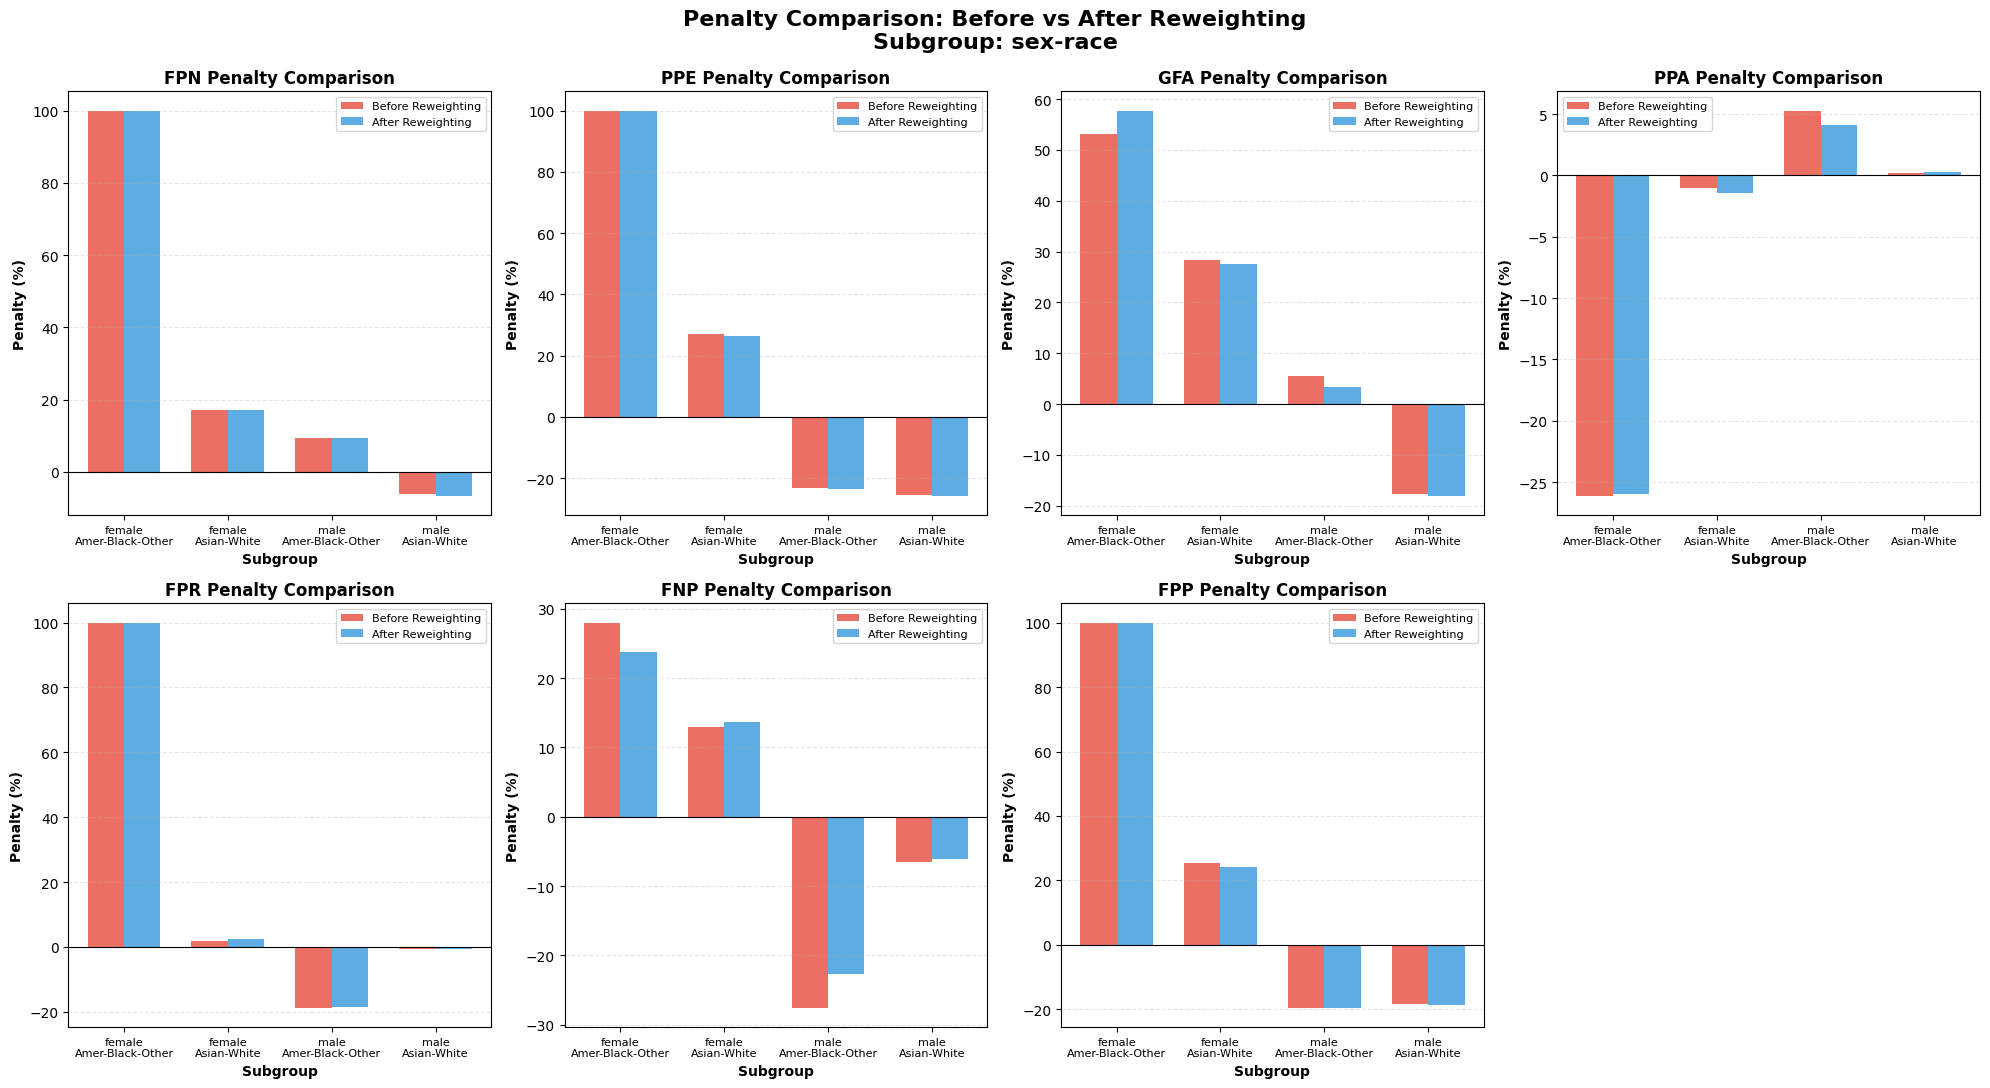

In [61]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

# Use the generalized function
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping)

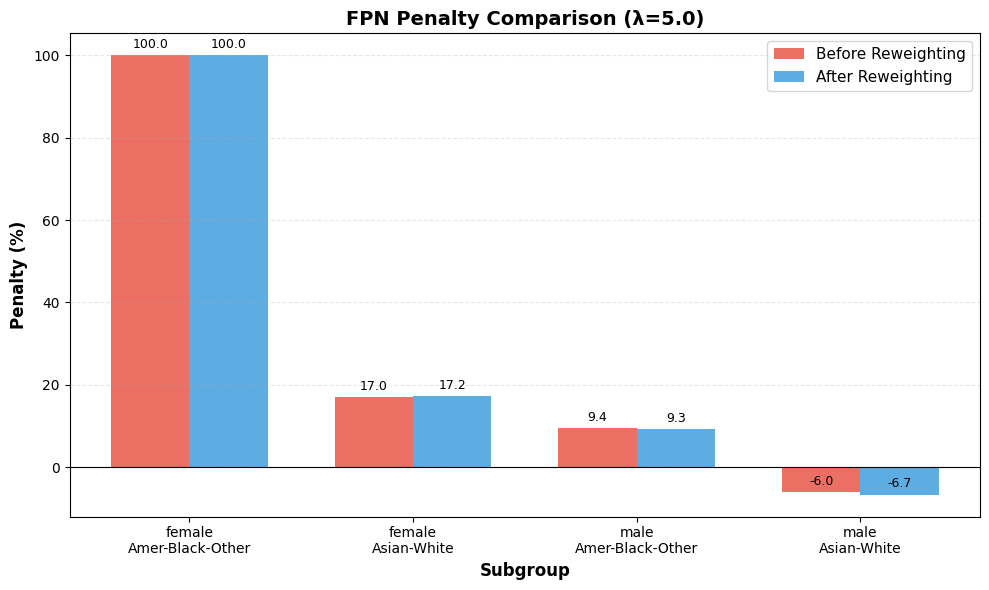


FPN - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 100.00 (Δ = +0.00)
  female-Asian-White: 17.01 → 17.16 (Δ = +0.16)
  male-Amer-Black-Other: 9.41 → 9.29 (Δ = -0.12)
  male-Asian-White: -6.00 → -6.67 (Δ = -0.66)
------------------------------------------------------------


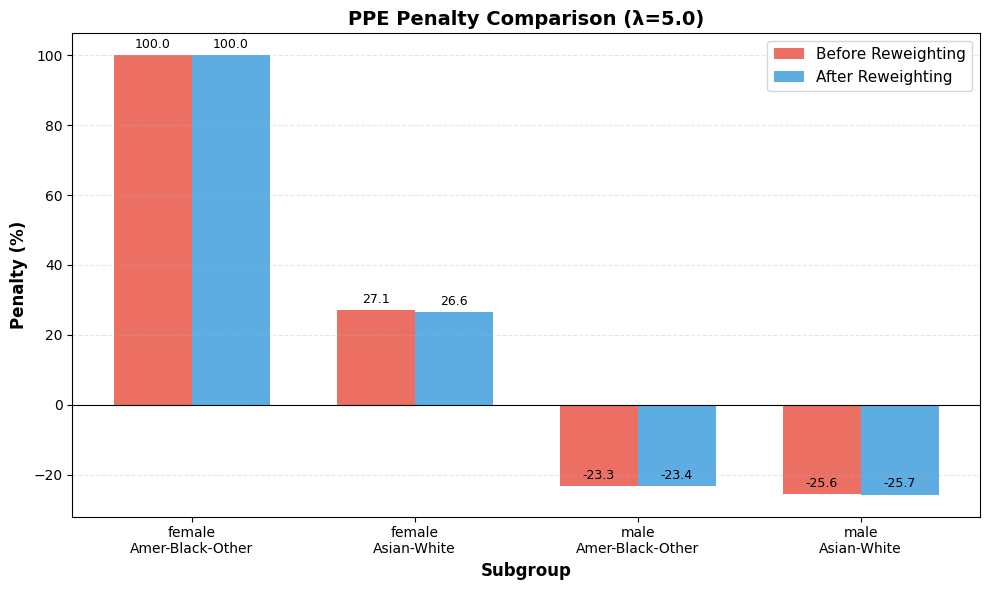


PPE - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 100.00 (Δ = +0.00)
  female-Asian-White: 27.12 → 26.55 (Δ = -0.57)
  male-Amer-Black-Other: -23.29 → -23.42 (Δ = -0.13)
  male-Asian-White: -25.56 → -25.74 (Δ = -0.18)
------------------------------------------------------------


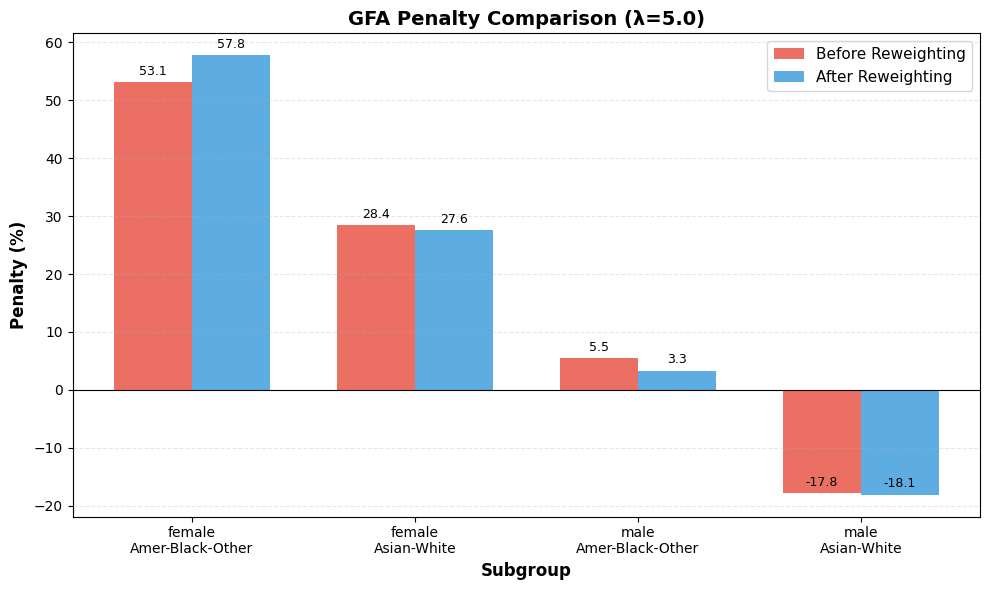


GFA - Penalty Changes:
  female-Amer-Black-Other: 53.11 → 57.75 (Δ = +4.65)
  female-Asian-White: 28.40 → 27.63 (Δ = -0.77)
  male-Amer-Black-Other: 5.48 → 3.33 (Δ = -2.15)
  male-Asian-White: -17.78 → -18.07 (Δ = -0.29)
------------------------------------------------------------


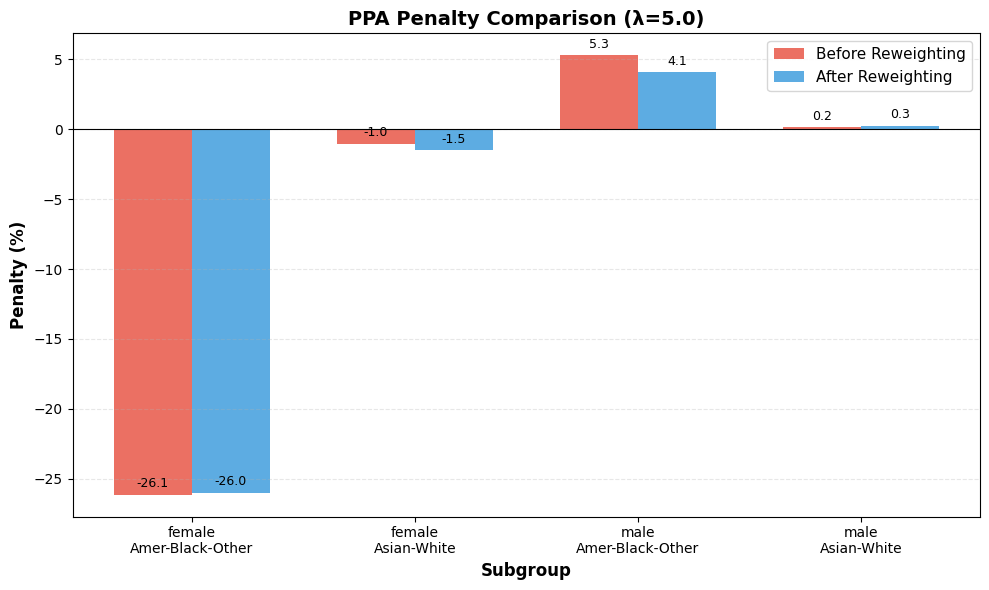


PPA - Penalty Changes:
  female-Amer-Black-Other: -26.12 → -25.98 (Δ = +0.15)
  female-Asian-White: -1.03 → -1.47 (Δ = -0.44)
  male-Amer-Black-Other: 5.28 → 4.08 (Δ = -1.20)
  male-Asian-White: 0.17 → 0.25 (Δ = +0.09)
------------------------------------------------------------


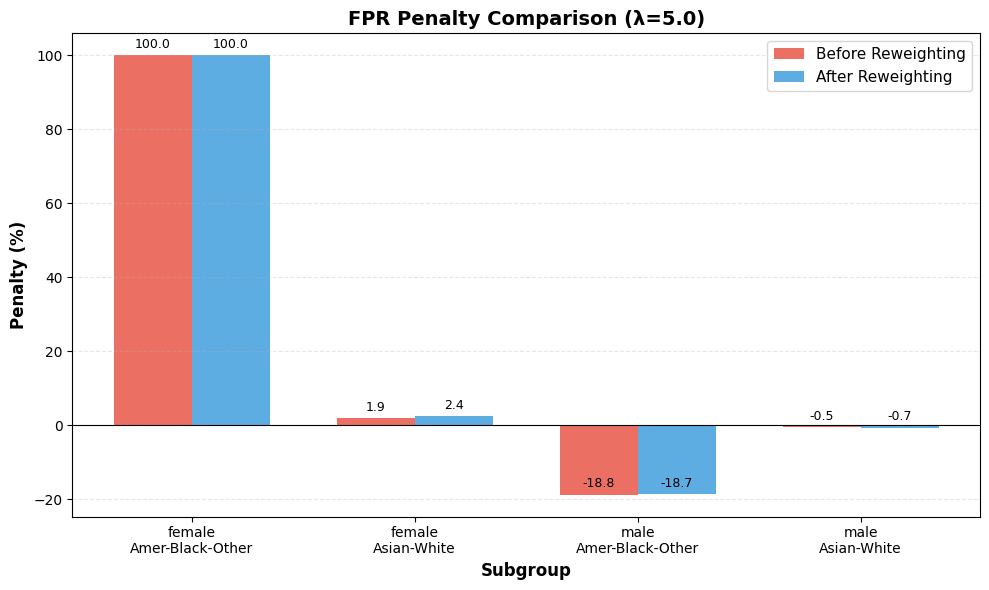


FPR - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 100.00 (Δ = +0.00)
  female-Asian-White: 1.86 → 2.39 (Δ = +0.52)
  male-Amer-Black-Other: -18.78 → -18.67 (Δ = +0.11)
  male-Asian-White: -0.49 → -0.65 (Δ = -0.16)
------------------------------------------------------------


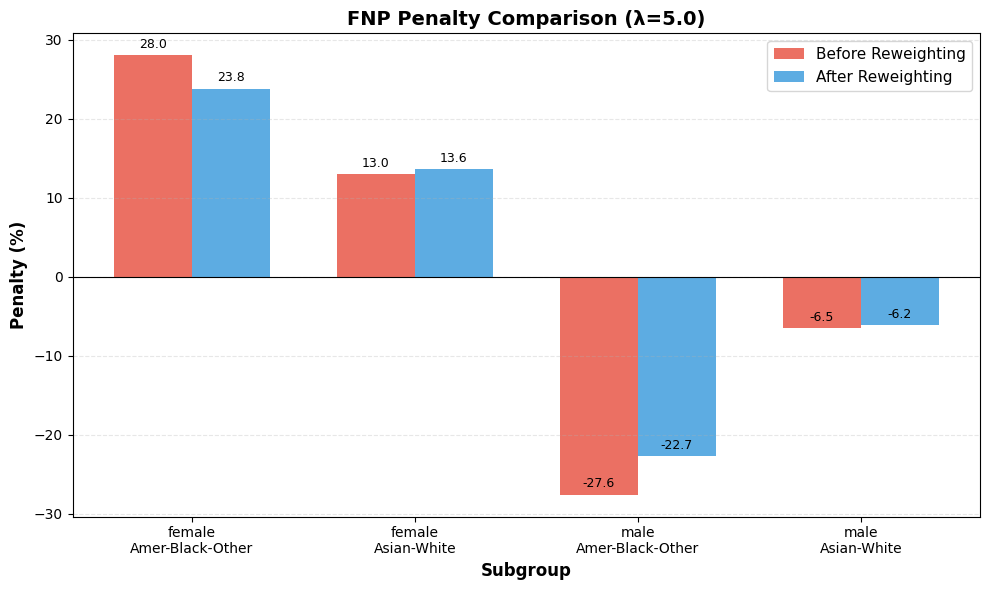


FNP - Penalty Changes:
  female-Amer-Black-Other: 28.00 → 23.79 (Δ = -4.21)
  female-Asian-White: 12.96 → 13.62 (Δ = +0.67)
  male-Amer-Black-Other: -27.56 → -22.72 (Δ = +4.84)
  male-Asian-White: -6.54 → -6.16 (Δ = +0.38)
------------------------------------------------------------


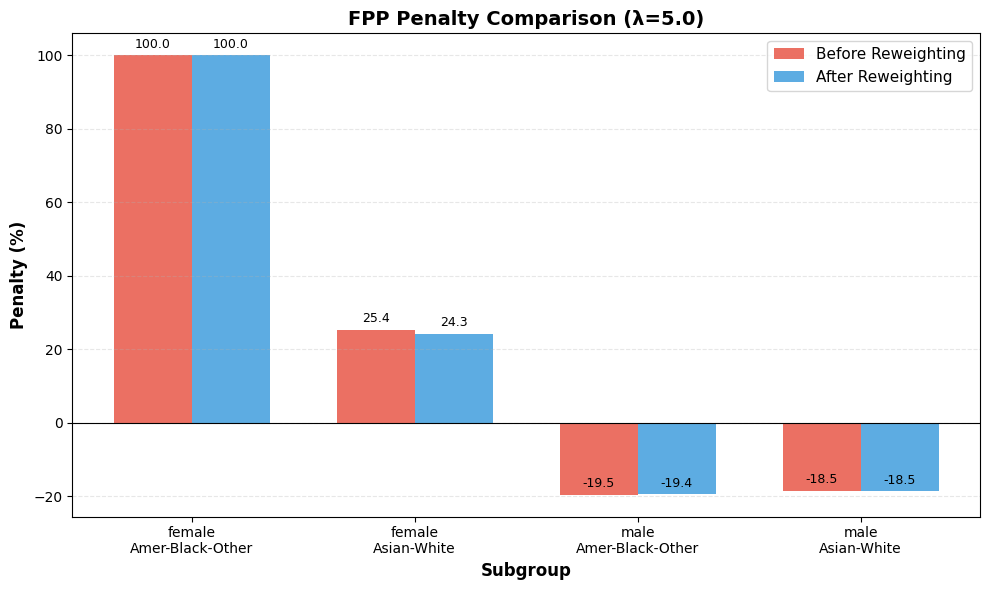


FPP - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 100.00 (Δ = +0.00)
  female-Asian-White: 25.35 → 24.27 (Δ = -1.08)
  male-Amer-Black-Other: -19.52 → -19.45 (Δ = +0.08)
  male-Asian-White: -18.46 → -18.49 (Δ = -0.03)
------------------------------------------------------------


In [62]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        # Decode subgroup labels using mapping
        decoded_labels = []
        for group in subgroups:
            sex_code = group[0]
            race_code = group[1]
            sex_label = mapping['sex'][int(sex_code)]
            race_label = mapping['race'][int(race_code)]
            decoded_labels.append(f"{sex_label}\n{race_label}")
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison (λ=5.0)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping)

---

# Analysis of subgroup distribution

1. **How many samples per subgroup?**
2. **How many positive (y=1) vs negative (y=0) per subgroup?**
3. **Is each subgroup balanced enough?**

### Utils

In [63]:
# Step 1: Analyze Subgroup Distribution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the full dataset
df_analysis = pd.read_csv(dataset_path)

# Create combined attribute column
individual_attrs = sensible_attribute.split('-')
df_analysis[sensible_attribute] = df_analysis[individual_attrs[0]].astype(str) + df_analysis[individual_attrs[1]].astype(str)

print("="*100)
print("SUBGROUP DISTRIBUTION ANALYSIS")
print("="*100)
print(f"\nDataset: {dataset_path}")
print(f"Total samples: {len(df_analysis)}")
print(f"Sensitive attribute: {sensible_attribute}")
print(f"Target variable: {target_variable}")

# Get all subgroups
subgroups = sorted(df_analysis[sensible_attribute].unique())

# Create summary table
print("\n" + "-"*100)
print(f"{'Subgroup':<12} | {'Decoded':<25} | {'Total':>8} | {'Pos (y=1)':>10} | {'Neg (y=0)':>10} | {'Pos Rate':>10} | {'Balanced?':>10}")
print("-"*100)

distribution_data = []

for group in subgroups:
    # Decode the group
    decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
    
    # Get counts
    group_data = df_analysis[df_analysis[sensible_attribute] == group]
    total = len(group_data)
    positive = (group_data[target_variable] == 1).sum()
    negative = (group_data[target_variable] == 0).sum()
    pos_rate = positive / total if total > 0 else 0
    
    # Determine if balanced (within 40-60% range for positive rate)
    balanced = "Yes" if 0.3 <= pos_rate <= 0.7 else "No"
    
    # Check if we can extract 10+10 anchor samples
    can_anchor_10 = "✓" if positive >= 10 and negative >= 10 else "✗"
    
    distribution_data.append({
        'group': group,
        'decoded': decoded,
        'total': total,
        'positive': positive,
        'negative': negative,
        'pos_rate': pos_rate,
        'balanced': balanced,
        'can_anchor_10': can_anchor_10
    })
    
    print(f"{group:<12} | {decoded:<25} | {total:>8} | {positive:>10} | {negative:>10} | {pos_rate:>9.1%} | {balanced:>10}")

print("-"*100)

# Summary statistics
print("\n" + "="*100)
print("FEASIBILITY CHECK: Can we extract anchor samples?")
print("="*100)

for n_anchor in [5, 10, 15, 20]:
    print(f"\n{n_anchor} positive + {n_anchor} negative per subgroup:")
    for d in distribution_data:
        can = "✓" if d['positive'] >= n_anchor and d['negative'] >= n_anchor else "✗"
        shortage_pos = max(0, n_anchor - d['positive'])
        shortage_neg = max(0, n_anchor - d['negative'])
        status = "OK" if can == "✓" else f"Need +{shortage_pos} pos, +{shortage_neg} neg"
        print(f"  {d['group']} ({d['decoded']:18s}): {can} {status}")

SUBGROUP DISTRIBUTION ANALYSIS

Dataset: AdultCensus/adult-preprocessed-2race-2age-2edu.csv
Total samples: 32561
Sensitive attribute: sex-race
Target variable: income

----------------------------------------------------------------------------------------------------
Subgroup     | Decoded                   |    Total |  Pos (y=1) |  Neg (y=0) |   Pos Rate |  Balanced?
----------------------------------------------------------------------------------------------------
00           | female-Amer-Black-Other   |     1783 |        108 |       1675 |      6.1% |         No
01           | female-Asian-White        |     8988 |       1071 |       7917 |     11.9% |         No
10           | male-Amer-Black-Other     |     1923 |        340 |       1583 |     17.7% |         No
11           | male-Asian-White          |    19867 |       6322 |      13545 |     31.8% |        Yes
----------------------------------------------------------------------------------------------------

FEASIBILITY 

In [78]:
# Detailed view: Distribution within each split (train/val/test)
from sklearn.model_selection import train_test_split

print("="*100)
print("DISTRIBUTION ACROSS TRAIN/VAL/TEST SPLITS (Current Random Split)")
print("="*100)

# Use current split
Y = df_analysis[target_variable]
X = df_analysis.drop(target_variable, axis=1)

# Recreate the splits
X_train_temp, X_temp, y_train_temp, y_temp = train_test_split(X, Y, test_size=0.3, random_state=1)
X_val_temp, X_test_temp, y_val_temp, y_test_temp = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

splits = {
    'Train (70%)': (X_train_temp, y_train_temp),
    'Val (15%)': (X_val_temp, y_val_temp),
    'Test (15%)': (X_test_temp, y_test_temp)
}

# Analyze each split
for split_name, (X_split, y_split) in splits.items():
    print(f"\n{split_name}:")
    print("-"*90)
    print(f"  {'Subgroup':<12} | {'Decoded':<20} | {'Total':>8} | {'Pos':>8} | {'Neg':>8} | {'Pos Rate':>10}")
    print("  " + "-"*80)
    
    # Get sensitive attribute for this split
    sens_split = df_analysis[sensible_attribute].loc[X_split.index]
    
    for group in subgroups:
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        mask = sens_split == group
        total = mask.sum()
        positive = (y_split[mask] == 1).sum()
        negative = (y_split[mask] == 0).sum()
        pos_rate = positive / total if total > 0 else 0
        
        print(f"  {group:<12} | {decoded:<20} | {total:>8} | {positive:>8} | {negative:>8} | {pos_rate:>9.1%}")

print("\n" + "="*100)
print("KEY OBSERVATION: Check if any subgroup has 0 positives or 0 negatives in any split!")
print("="*100)

DISTRIBUTION ACROSS TRAIN/VAL/TEST SPLITS (Current Random Split)

Train (70%):
------------------------------------------------------------------------------------------
  Subgroup     | Decoded              |    Total |      Pos |      Neg |   Pos Rate
  --------------------------------------------------------------------------------
  00           | female-Amer-Black-Other |     1250 |       73 |     1177 |      5.8%
  01           | female-Asian-White   |     6262 |      745 |     5517 |     11.9%
  10           | male-Amer-Black-Other |     1342 |      233 |     1109 |     17.4%
  11           | male-Asian-White     |    13938 |     4389 |     9549 |     31.5%

Val (15%):
------------------------------------------------------------------------------------------
  Subgroup     | Decoded              |    Total |      Pos |      Neg |   Pos Rate
  --------------------------------------------------------------------------------
  00           | female-Amer-Black-Other |      246 |    

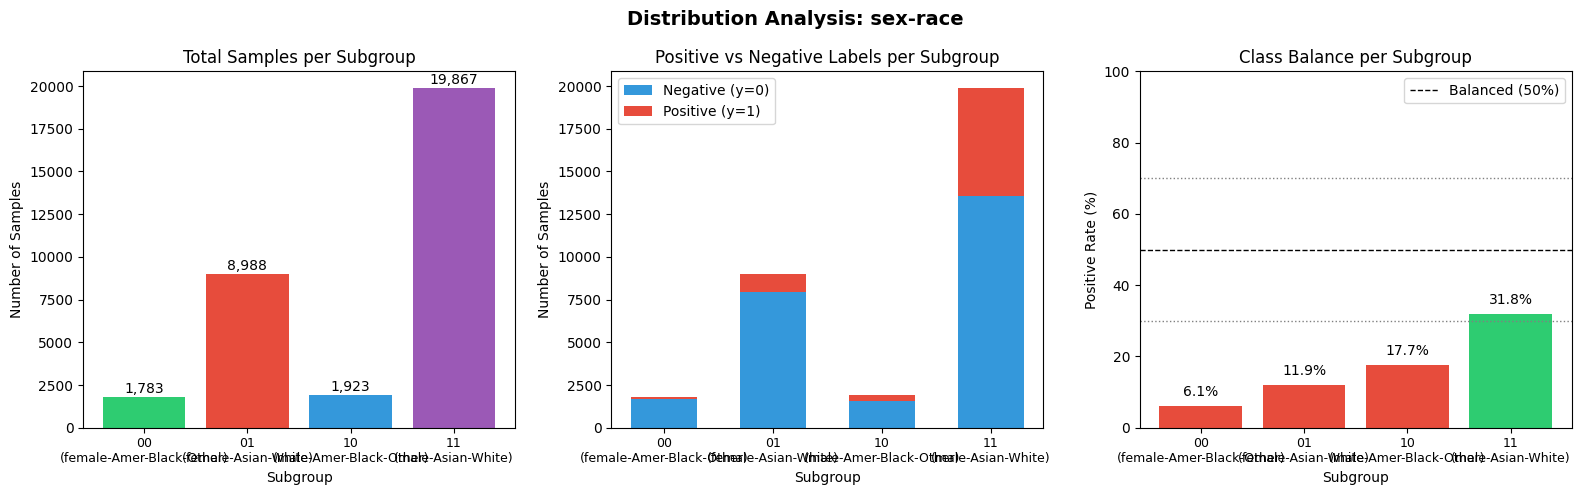

In [64]:
# Visualization: Subgroup Distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Total samples per subgroup
ax1 = axes[0]
groups = [d['group'] for d in distribution_data]
totals = [d['total'] for d in distribution_data]
decoded_labels = [d['decoded'] for d in distribution_data]

bars = ax1.bar(groups, totals, color=['#2ecc71', '#e74c3c', '#3498db', '#9b59b6'])
ax1.set_xlabel('Subgroup')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Total Samples per Subgroup')
ax1.set_xticks(range(len(groups)))
ax1.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)

# Add value labels on bars
for bar, total in zip(bars, totals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{total:,}', ha='center', va='bottom', fontsize=10)

# Plot 2: Positive vs Negative per subgroup (stacked)
ax2 = axes[1]
positives = [d['positive'] for d in distribution_data]
negatives = [d['negative'] for d in distribution_data]

x = np.arange(len(groups))
width = 0.6

bars_neg = ax2.bar(x, negatives, width, label='Negative (y=0)', color='#3498db')
bars_pos = ax2.bar(x, positives, width, bottom=negatives, label='Positive (y=1)', color='#e74c3c')

ax2.set_xlabel('Subgroup')
ax2.set_ylabel('Number of Samples')
ax2.set_title('Positive vs Negative Labels per Subgroup')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
ax2.legend()

# Plot 3: Positive rate per subgroup
ax3 = axes[2]
pos_rates = [d['pos_rate'] * 100 for d in distribution_data]

bars = ax3.bar(groups, pos_rates, color=['#2ecc71' if 30 <= r <= 70 else '#e74c3c' for r in pos_rates])
ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, label='Balanced (50%)')
ax3.axhline(y=30, color='gray', linestyle=':', linewidth=1)
ax3.axhline(y=70, color='gray', linestyle=':', linewidth=1)
ax3.set_xlabel('Subgroup')
ax3.set_ylabel('Positive Rate (%)')
ax3.set_title('Class Balance per Subgroup')
ax3.set_xticks(range(len(groups)))
ax3.set_xticklabels([f"{g}\n({d})" for g, d in zip(groups, decoded_labels)], fontsize=9)
ax3.set_ylim(0, 100)
ax3.legend()

# Add value labels
for bar, rate in zip(bars, pos_rates):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Distribution Analysis: {sensible_attribute}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

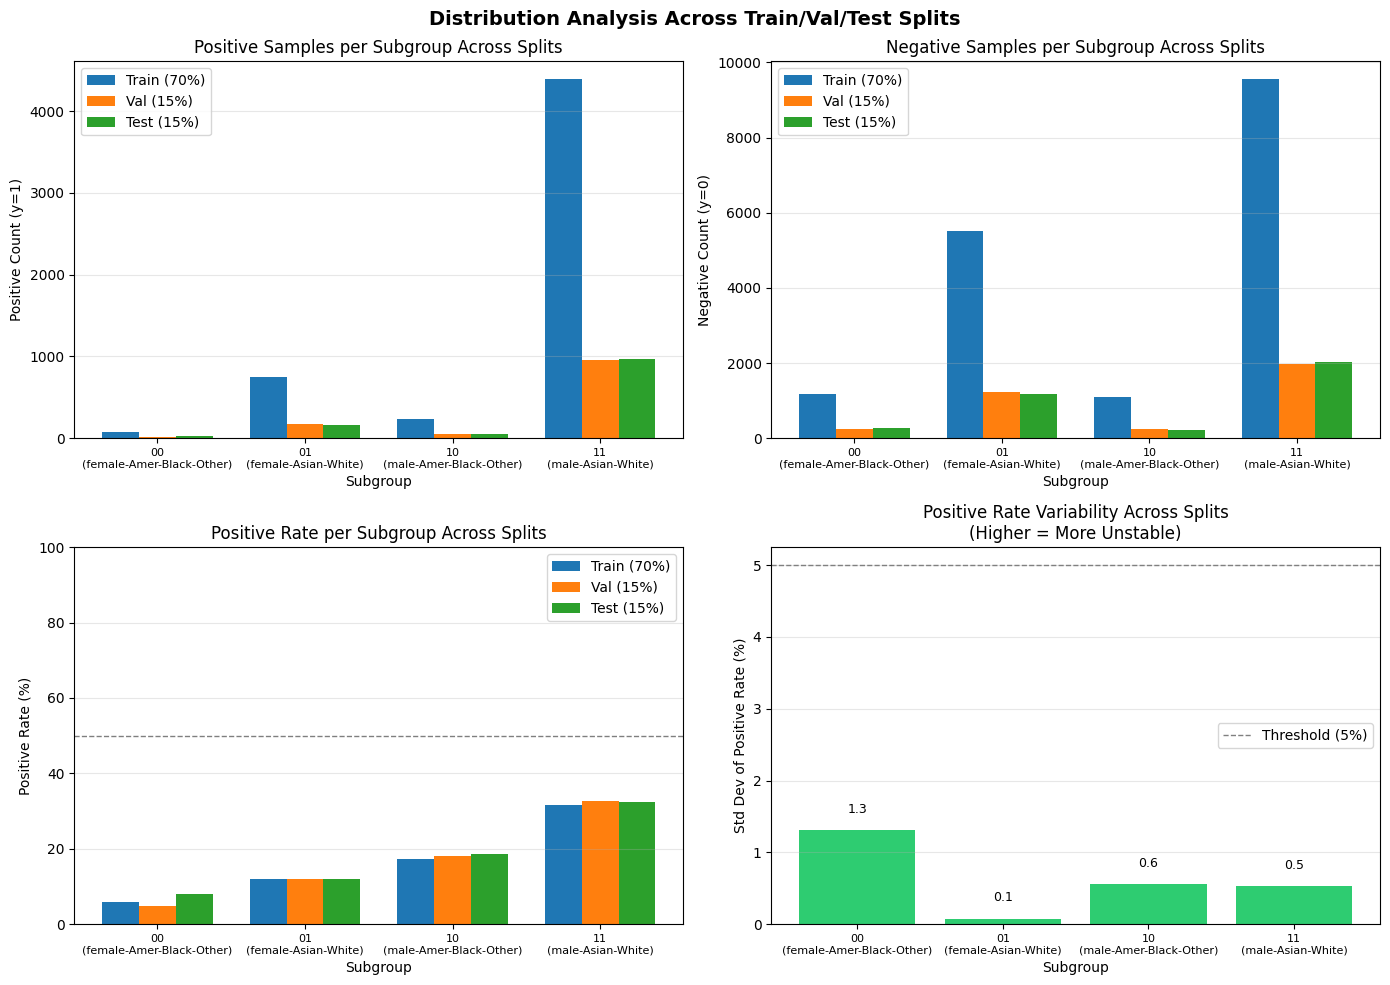


INTERPRETATION:
- High variance in positive rate suggests the split is unstable for that subgroup
- Subgroups with variance > 5% may benefit from fixed anchor samples
- Small subgroups tend to have higher variance due to random sampling effects


In [66]:
# Visualization: Compare distributions across splits
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Collect data for all splits
split_data = {}
for split_name, (X_split, y_split) in splits.items():
    sens_split = df_analysis[sensible_attribute].loc[X_split.index]
    split_data[split_name] = {
        'pos': [],
        'neg': [],
        'pos_rate': []
    }
    for group in subgroups:
        mask = sens_split == group
        positive = (y_split[mask] == 1).sum()
        negative = (y_split[mask] == 0).sum()
        total = positive + negative
        split_data[split_name]['pos'].append(positive)
        split_data[split_name]['neg'].append(negative)
        split_data[split_name]['pos_rate'].append(positive / total * 100 if total > 0 else 0)

# Plot 1: Positive counts across splits
ax1 = axes[0, 0]
x = np.arange(len(subgroups))
width = 0.25
for i, (split_name, data) in enumerate(split_data.items()):
    ax1.bar(x + i*width, data['pos'], width, label=split_name)
ax1.set_xlabel('Subgroup')
ax1.set_ylabel('Positive Count (y=1)')
ax1.set_title('Positive Samples per Subgroup Across Splits')
ax1.set_xticks(x + width)
ax1.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Negative counts across splits
ax2 = axes[0, 1]
for i, (split_name, data) in enumerate(split_data.items()):
    ax2.bar(x + i*width, data['neg'], width, label=split_name)
ax2.set_xlabel('Subgroup')
ax2.set_ylabel('Negative Count (y=0)')
ax2.set_title('Negative Samples per Subgroup Across Splits')
ax2.set_xticks(x + width)
ax2.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Positive rate comparison across splits
ax3 = axes[1, 0]
for i, (split_name, data) in enumerate(split_data.items()):
    ax3.bar(x + i*width, data['pos_rate'], width, label=split_name)
ax3.axhline(y=50, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('Subgroup')
ax3.set_ylabel('Positive Rate (%)')
ax3.set_title('Positive Rate per Subgroup Across Splits')
ax3.set_xticks(x + width)
ax3.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 100)

# Plot 4: Variance in positive rate across splits (indicator of instability)
ax4 = axes[1, 1]
pos_rate_variance = []
for i, group in enumerate(subgroups):
    rates = [split_data[split]['pos_rate'][i] for split in split_data.keys()]
    variance = np.std(rates)
    pos_rate_variance.append(variance)

bars = ax4.bar(subgroups, pos_rate_variance, color=['#e74c3c' if v > 5 else '#2ecc71' for v in pos_rate_variance])
ax4.set_xlabel('Subgroup')
ax4.set_ylabel('Std Dev of Positive Rate (%)')
ax4.set_title('Positive Rate Variability Across Splits\n(Higher = More Unstable)')
ax4.set_xticks(range(len(subgroups)))
ax4.set_xticklabels([f"{g}\n({decoded_labels[i]})" for i, g in enumerate(subgroups)], fontsize=8)
ax4.axhline(y=5, color='gray', linestyle='--', linewidth=1, label='Threshold (5%)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, var in zip(bars, pos_rate_variance):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, 
             f'{var:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution Analysis Across Train/Val/Test Splits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*100)
print("INTERPRETATION:")
print("="*100)
print("- High variance in positive rate suggests the split is unstable for that subgroup")
print("- Subgroups with variance > 5% may benefit from fixed anchor samples")
print("- Small subgroups tend to have higher variance due to random sampling effects")

# K-Fold Cross-Validation for Penalty Estimation

**Goal**: Get more stable penalty estimates by averaging across 5 validation folds.

**Process**:
1. Combine Train + Val data (85% of total)
2. Split into 5 folds using StratifiedKFold (preserves class balance)
3. For each fold: train on 4 folds, validate on 1 fold, compute penalties
4. Average penalties across all 5 folds
5. Use averaged penalties to compute final weights
6. Train final model on ALL train+val data with weights → Predict on Test

**Test set (15%) remains completely separate!**

In [67]:
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb

def compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5, verbose=True):
    """
    Compute penalties using K-Fold cross-validation for more stable estimates.
    
    Args:
        sensible_attribute: Combined attribute like 'sex-race'
        fair_metrics: List of fairness metrics to compute penalties for
        n_folds: Number of folds (default 5)
        verbose: Print progress
    
    Returns:
        penalties_kfold_avg: Dict of {metric: {subgroup: averaged_penalty}}
        penalties_per_fold: Dict of {metric: {subgroup: [penalties_per_fold]}}
    """
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    
    # Combine train + validation data
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    if verbose:
        print("="*80)
        print(f"K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K={n_folds})")
        print("="*80)
        print(f"Train+Val samples: {len(X_trainval)}")
        print(f"Test samples (held out): {len(X_test[sensible_attribute])}")
    
    # Initialize storage for penalties per fold
    penalties_per_fold = {m: {g: [] for g in ['00', '01', '10', '11']} for m in fair_metrics}
    
    # Setup stratified K-fold
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Load dataframe once for fairness computation
    df_original = pd.read_csv(dataset_path)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
        if verbose:
            print(f"\n--- Fold {fold_idx + 1}/{n_folds} ---")
        
        # Split data for this fold
        X_fold_train = X_trainval.iloc[train_idx]
        y_fold_train = y_trainval.iloc[train_idx]
        X_fold_val = X_trainval.iloc[val_idx]
        y_fold_val = y_trainval.iloc[val_idx]
        
        if verbose:
            # Show distribution in this fold's validation set
            val_dist = X_fold_val[sensible_attribute].value_counts().sort_index()
            print(f"  Val distribution: {val_dist.to_dict()}")
        
        # Convert to numeric for XGBoost
        X_fold_train_num = X_fold_train.copy()
        X_fold_train_num[sensible_attribute] = X_fold_train_num[sensible_attribute].astype('category').cat.codes
        
        X_fold_val_num = X_fold_val.copy()
        X_fold_val_num[sensible_attribute] = X_fold_val_num[sensible_attribute].astype('category').cat.codes
        
        # Train model on this fold's training data
        model_fold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
        model_fold.fit(X_fold_train_num, y_fold_train)
        
        # Predict on this fold's validation data
        y_pred_fold_val = model_fold.predict(X_fold_val_num)
        
        # Compute fairness metrics for each attribute
        fairness_metrics_fold = {}
        
        for attribute in attributes:
            df_attr = df_original.copy()
            
            if '-' in attribute:
                indiv_attrs = attribute.split('-')
                df_attr[attribute] = reduce(
                    lambda x, y: x.astype(str) + y.astype(str),
                    [df_attr[col] for col in indiv_attrs]
                )
            
            # Get sensible indexes for this fold's validation set
            sensible_indexes_fold = df_attr[attribute].loc[list(X_fold_val.index)]
            
            # Compute confusion matrix
            cm_dict_fold = compute_cm_group(
                df_attr, attribute, sensible_indexes_fold,
                y_pred_fold_val, y_fold_val, X_fold_val, target_variable_labels
            )
            
            # Compute fairness metrics
            fairness_metrics_fold[attribute] = {}
            for m in fair_metrics:
                fairness_metrics_fold[attribute][m], _ = compute_fairness_metrics_and_counts(
                    cm_dict_fold, m, attribute, mapping, dataset_path
                )
        
        # Compute penalties for each metric
        for m in fair_metrics:
            penalty_harm, _, _ = compute_penalty_2(
                fairness_metrics_fold, df_original,
                individual_attrs[0], individual_attrs[1], m
            )
            
            # Store penalty for each subgroup
            for group, penalty in penalty_harm.items():
                penalties_per_fold[m][group].append(penalty)
    
    # Average penalties across folds
    penalties_kfold_avg = {}
    for m in fair_metrics:
        penalties_kfold_avg[m] = {}
        for group in ['00', '01', '10', '11']:
            fold_penalties = penalties_per_fold[m][group]
            penalties_kfold_avg[m][group] = np.mean(fold_penalties)
    
    if verbose:
        print("\n" + "="*80)
        print("AVERAGED PENALTIES (across 5 folds)")
        print("="*80)
        for m in fair_metrics[:3]:  # Show first 3 metrics
            print(f"\n{m}:")
            for group in ['00', '01', '10', '11']:
                avg = penalties_kfold_avg[m][group]
                std = np.std(penalties_per_fold[m][group])
                fold_vals = penalties_per_fold[m][group]
                print(f"  {group}: avg={avg:+.2f}%, std={std:.2f}, folds={[f'{v:.1f}' for v in fold_vals]}")
    
    return penalties_kfold_avg, penalties_per_fold

# Run K-fold penalty computation
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
penalties_kfold_avg, penalties_per_fold = compute_penalties_kfold(sensible_attribute, fair_metrics, n_folds=5)

K-FOLD CROSS-VALIDATION FOR PENALTY ESTIMATION (K=5)
Train+Val samples: 27676
Test samples (held out): 4885

--- Fold 1/5 ---
  Val distribution: {'00': 276, '01': 1619, '10': 300, '11': 3341}

--- Fold 2/5 ---
  Val distribution: {'00': 306, '01': 1472, '10': 341, '11': 3416}

--- Fold 3/5 ---
  Val distribution: {'00': 317, '01': 1545, '10': 361, '11': 3312}

--- Fold 4/5 ---
  Val distribution: {'00': 310, '01': 1500, '10': 339, '11': 3386}

--- Fold 5/5 ---
  Val distribution: {'00': 287, '01': 1529, '10': 299, '11': 3420}

AVERAGED PENALTIES (across 5 folds)

FPN:
  00: avg=+12.97%, std=55.40, folds=['48.3', '-17.0', '-7.2', '100.0', '-59.3']
  01: avg=+15.32%, std=8.68, folds=['17.4', '5.6', '7.7', '15.7', '30.1']
  10: avg=+16.93%, std=22.21, folds=['-11.1', '42.6', '31.5', '30.1', '-8.3']
  11: avg=-4.12%, std=0.90, folds=['-3.5', '-3.7', '-3.9', '-5.9', '-3.6']

PPE:
  00: avg=+57.54%, std=27.58, folds=['67.8', '59.6', '44.0', '100.0', '16.2']
  01: avg=+30.29%, std=6.66, fold

## Compute Weights Using K-Fold Averaged Penalties

### Functions

Now we use the more stable K-fold averaged penalties to compute weights, train the final model, and compare with the single-split approach.

### Functions

In [69]:
def compute_weights_kfold(lambda_=5.0, m='PPE'):
    """
    Compute weights using K-fold averaged penalties instead of single-split penalties.
    """
    # Combine train + val for final training
    X_trainval = pd.concat([X_train[sensible_attribute], X_val[sensible_attribute]])
    y_trainval = pd.concat([y_train[sensible_attribute], y_val[sensible_attribute]])
    
    weights_for_training = np.ones(len(X_trainval))
    
    # Use K-fold averaged penalties
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_kfold_avg[m].items()
    }
    
    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(X_trainval.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    print(f"Training samples: {len(weights_for_training)}, Weights per group (K-fold): {group_weights}")
    
    return weights_for_training, X_trainval, y_trainval

In [70]:
def compute_penalties_after_reweighting_kfold(weights, X_trainval, y_trainval, fairness_metric='PPE'):
    """
    Train model on FULL train+val data with K-fold weights, evaluate on test set.
    """
    # Convert to numeric for XGBoost
    X_trainval_num = X_trainval.copy()
    X_trainval_num[sensible_attribute] = X_trainval_num[sensible_attribute].astype('category').cat.codes
    
    X_test_num = X_test[sensible_attribute].copy()
    X_test_num[sensible_attribute] = X_test_num[sensible_attribute].astype('category').cat.codes
    
    # Train model on full train+val with weights
    model_kfold = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_kfold.fit(X_trainval_num, y_trainval, sample_weight=weights)
    
    # Predict on test set
    y_pred_test_kfold = model_kfold.predict(X_test_num)
    
    # Compute fairness metrics
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    individual_attrs = sensible_attribute.split('-')
    df_fresh = pd.read_csv(dataset_path)
    
    fairness_metrics_kfold = {}
    
    for attribute in attributes:
        df_attr = df_fresh.copy()
        
        if '-' in attribute:
            indiv_attrs = attribute.split('-')
            df_attr[attribute] = reduce(
                lambda x, y: x.astype(str) + y.astype(str),
                [df_attr[col] for col in indiv_attrs]
            )
        
        sensible_indexes_attr = df_attr[attribute].loc[list(X_test[sensible_attribute].index)]
        
        cm_dict_attr = compute_cm_group(
            df_attr, attribute, sensible_indexes_attr,
            y_pred_test_kfold, y_test[sensible_attribute], X_test[sensible_attribute],
            target_variable_labels
        )
        
        fairness_metrics_kfold[attribute] = {}
        for m in fair_metrics:
            fairness_metrics_kfold[attribute][m], _ = compute_fairness_metrics_and_counts(
                cm_dict_attr, m, attribute, mapping, dataset_path
            )
    
    # Compute penalties
    harmonic, _, _ = compute_penalty_2(
        fairness_metrics_kfold, df_fresh,
        individual_attrs[0], individual_attrs[1],
        fairness_metric
    )
    
    return harmonic

# Penalty plots on K-fold

### Weights and penalties computation

In [71]:
# Compute weights using K-fold penalties
weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, 'PPE')

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.8768973824712263), '01': np.float64(2.5143711324156217), '10': np.float64(1.046269285155348), '11': 0.01}


In [72]:
# Compute penalties on test set after K-fold reweighting
penalties_ontest_after_kfold = {}
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    weights_kfold, X_trainval, y_trainval = compute_weights_kfold(5.0, metric)
    penalties_ontest_after_kfold[metric] = compute_penalties_after_reweighting_kfold(
        weights_kfold, X_trainval, y_trainval, metric
    )
    
print("\nPenalties after K-fold reweighting computed for all metrics.")

Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.6482908903961535), '01': np.float64(1.7659501778535382), '10': np.float64(1.8464121705831142), '11': np.float64(0.7940159556548778)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.8768973824712263), '01': np.float64(2.5143711324156217), '10': np.float64(1.046269285155348), '11': 0.01}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(3.718604319244079), '01': np.float64(2.2733649802827083), '10': np.float64(1.2635069086732622), '11': np.float64(0.15248187352621922)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(1.0038850442000484), '01': np.float64(0.8656303230053926), '10': np.float64(0.8858241104195381), '11': np.float64(1.0178114724140443)}
Training samples: 27676, Weights per group (K-fold): {'00': np.float64(0.8025313608926784), '01': np.float64(0.7780072641178941), '10': np.float64(0.9155857374234886), '11': np.float64(1.1264524927854598

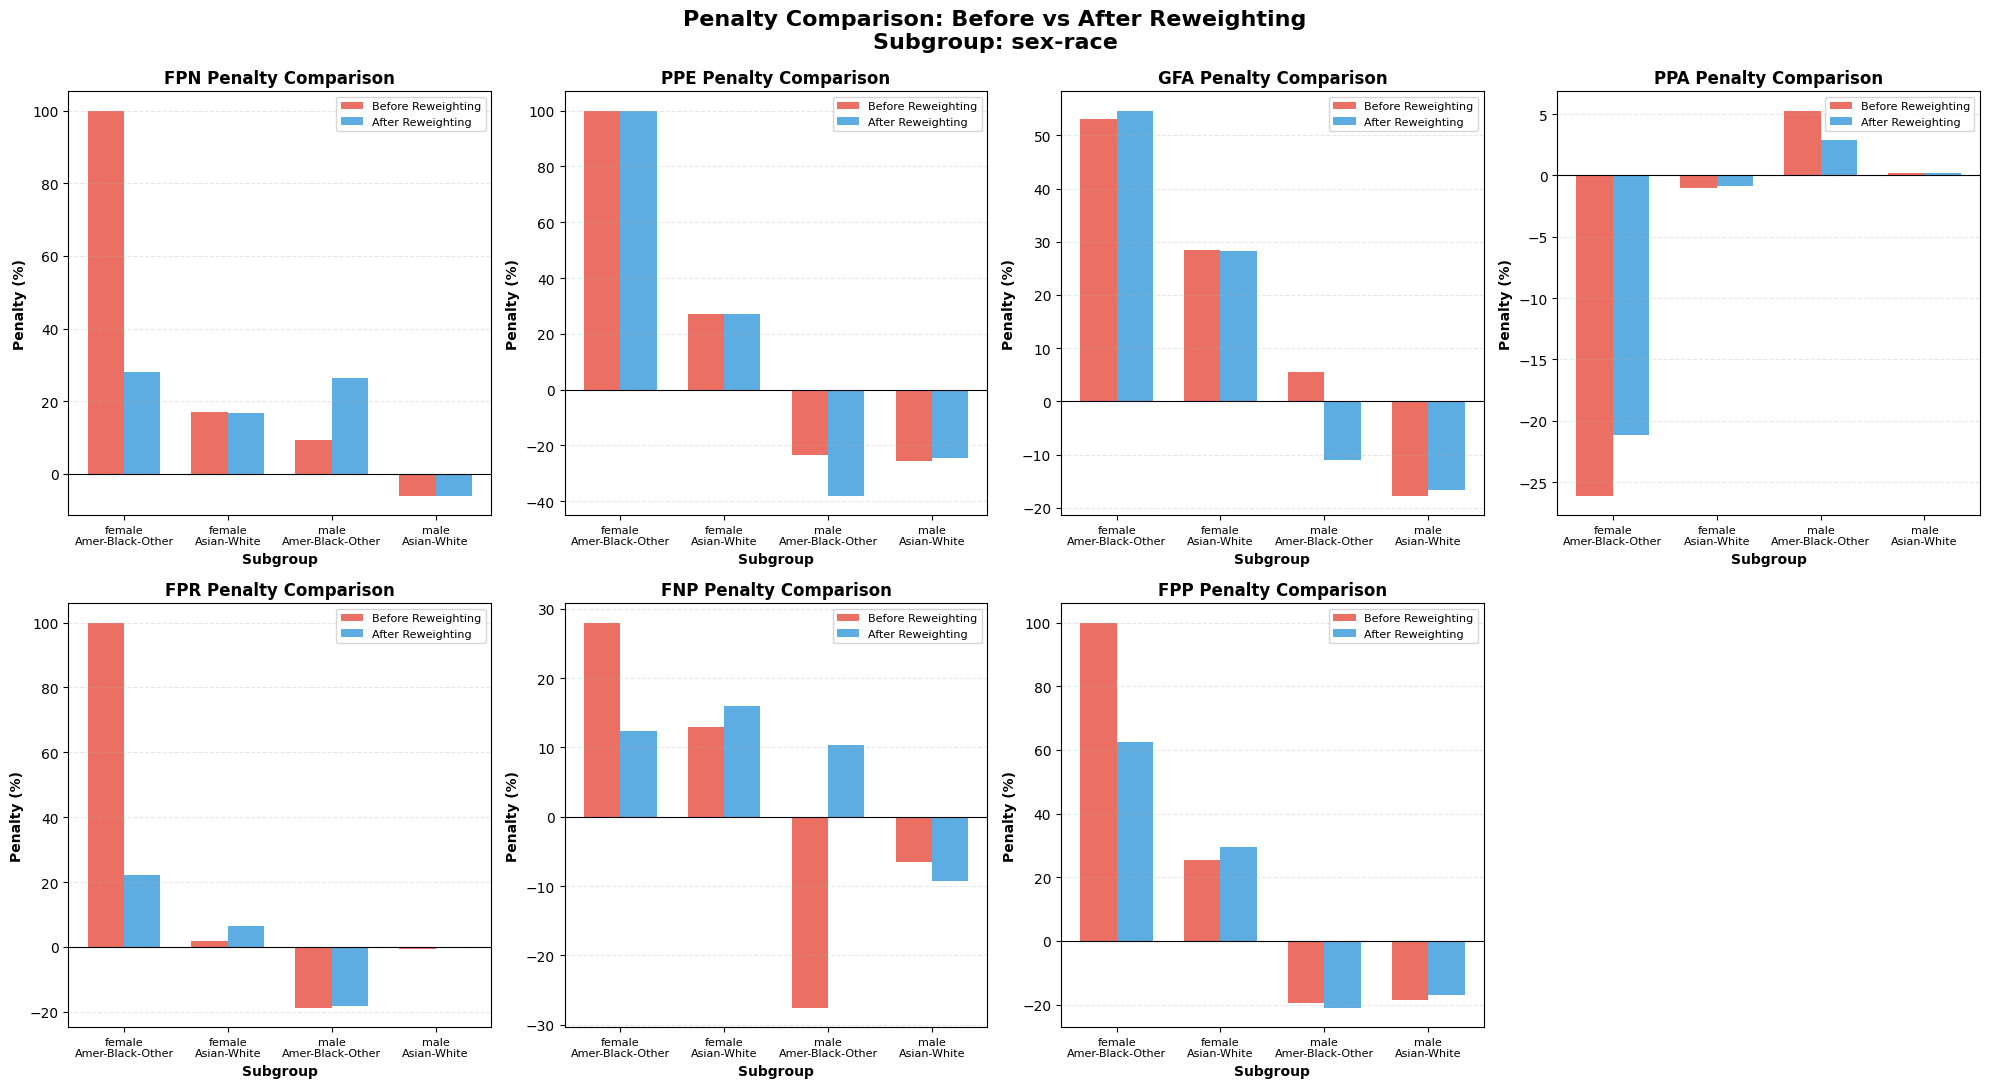

In [73]:
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_kfold,
                                        sensible_attribute, mapping)

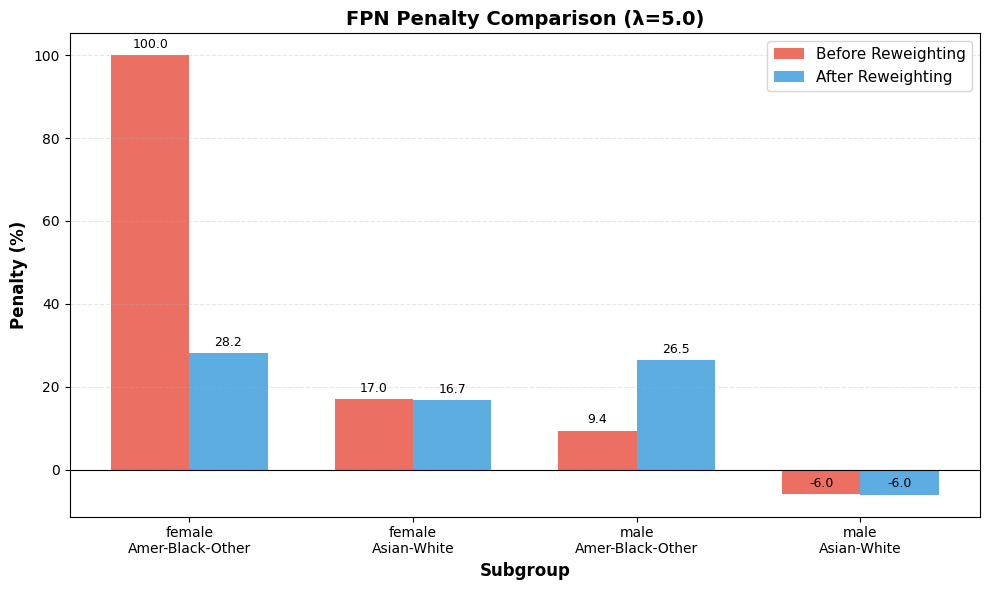


FPN - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 28.19 (Δ = -71.81)
  female-Asian-White: 17.01 → 16.71 (Δ = -0.30)
  male-Amer-Black-Other: 9.41 → 26.46 (Δ = +17.05)
  male-Asian-White: -6.00 → -6.04 (Δ = -0.04)
------------------------------------------------------------


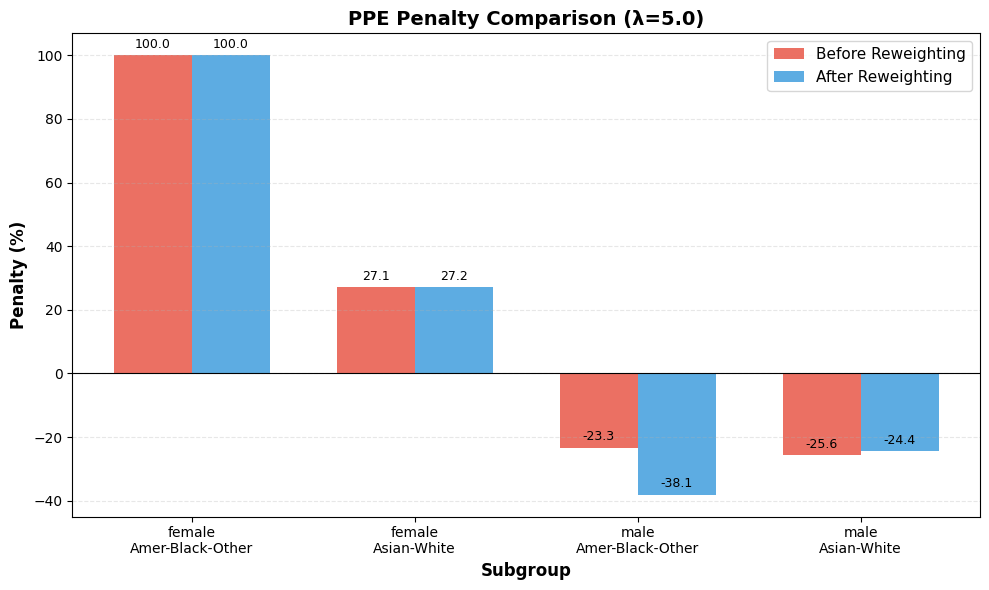


PPE - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 100.00 (Δ = +0.00)
  female-Asian-White: 27.12 → 27.17 (Δ = +0.04)
  male-Amer-Black-Other: -23.29 → -38.07 (Δ = -14.78)
  male-Asian-White: -25.56 → -24.43 (Δ = +1.13)
------------------------------------------------------------


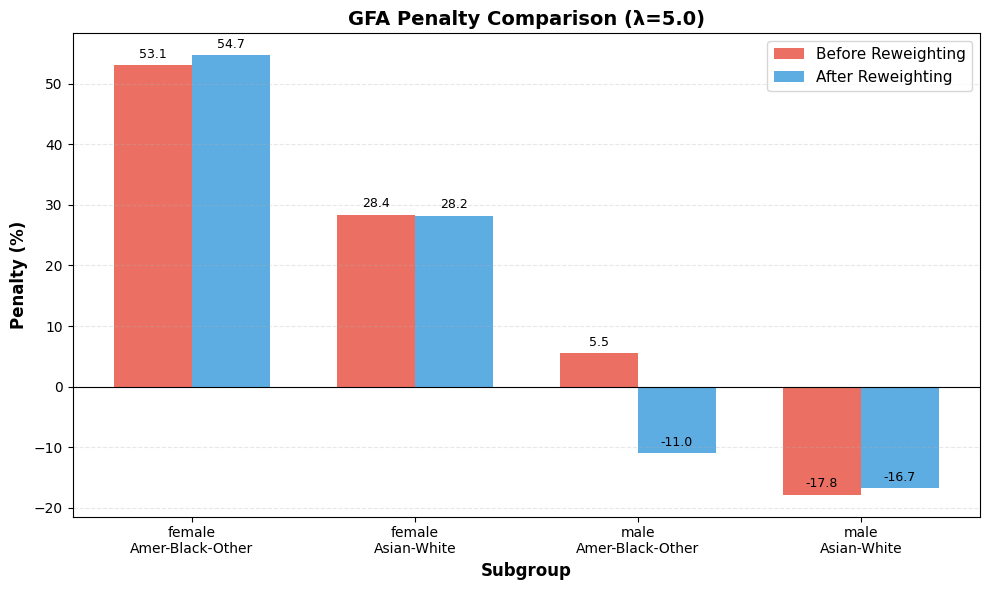


GFA - Penalty Changes:
  female-Amer-Black-Other: 53.11 → 54.66 (Δ = +1.55)
  female-Asian-White: 28.40 → 28.23 (Δ = -0.16)
  male-Amer-Black-Other: 5.48 → -10.95 (Δ = -16.43)
  male-Asian-White: -17.78 → -16.69 (Δ = +1.09)
------------------------------------------------------------


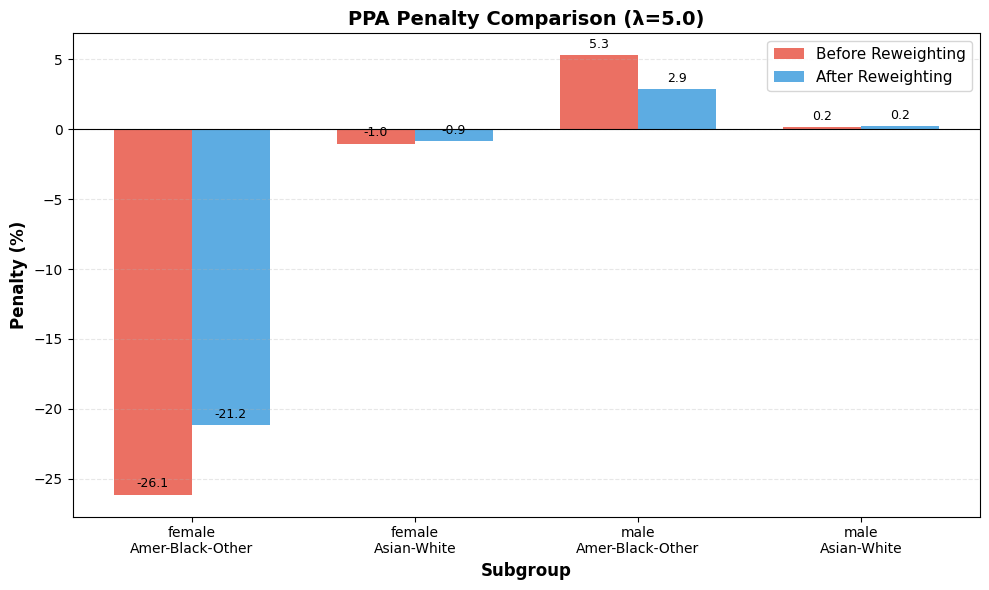


PPA - Penalty Changes:
  female-Amer-Black-Other: -26.12 → -21.17 (Δ = +4.95)
  female-Asian-White: -1.03 → -0.86 (Δ = +0.17)
  male-Amer-Black-Other: 5.28 → 2.87 (Δ = -2.41)
  male-Asian-White: 0.17 → 0.23 (Δ = +0.07)
------------------------------------------------------------


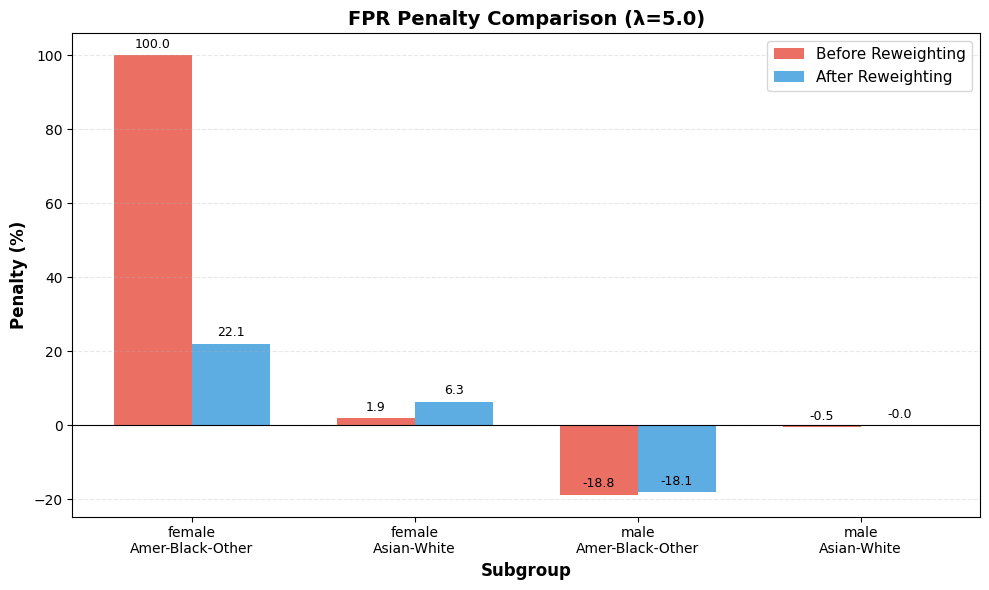


FPR - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 22.06 (Δ = -77.94)
  female-Asian-White: 1.86 → 6.35 (Δ = +4.48)
  male-Amer-Black-Other: -18.78 → -18.15 (Δ = +0.64)
  male-Asian-White: -0.49 → -0.02 (Δ = +0.47)
------------------------------------------------------------


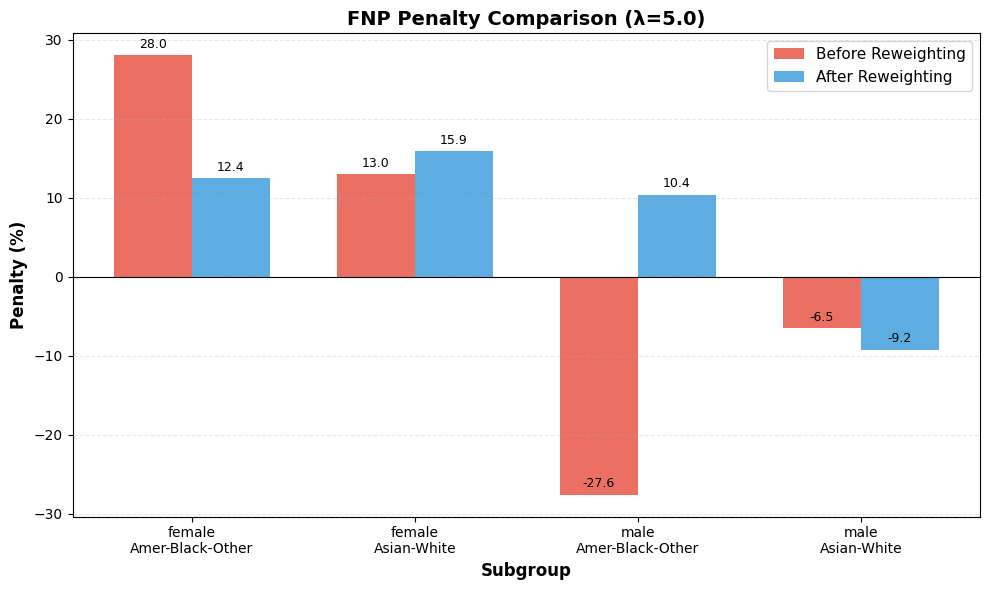


FNP - Penalty Changes:
  female-Amer-Black-Other: 28.00 → 12.43 (Δ = -15.57)
  female-Asian-White: 12.96 → 15.93 (Δ = +2.98)
  male-Amer-Black-Other: -27.56 → 10.39 (Δ = +37.95)
  male-Asian-White: -6.54 → -9.22 (Δ = -2.68)
------------------------------------------------------------


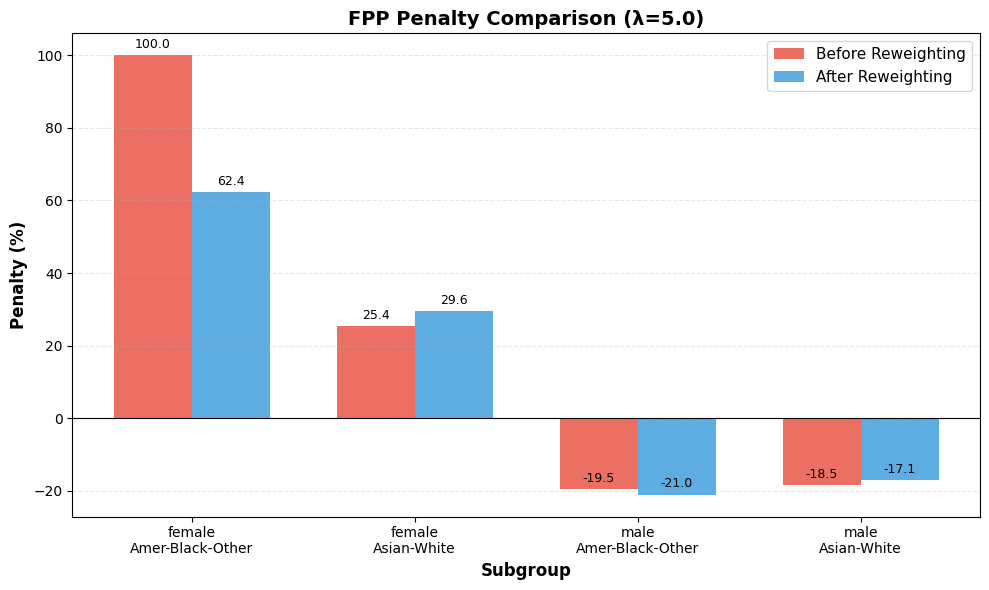


FPP - Penalty Changes:
  female-Amer-Black-Other: 100.00 → 62.37 (Δ = -37.63)
  female-Asian-White: 25.35 → 29.62 (Δ = +4.26)
  male-Amer-Black-Other: -19.52 → -21.01 (Δ = -1.49)
  male-Asian-White: -18.46 → -17.09 (Δ = +1.36)
------------------------------------------------------------


In [74]:
plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_kfold, sensible_attribute, mapping)

---

# Additional Plots and Info

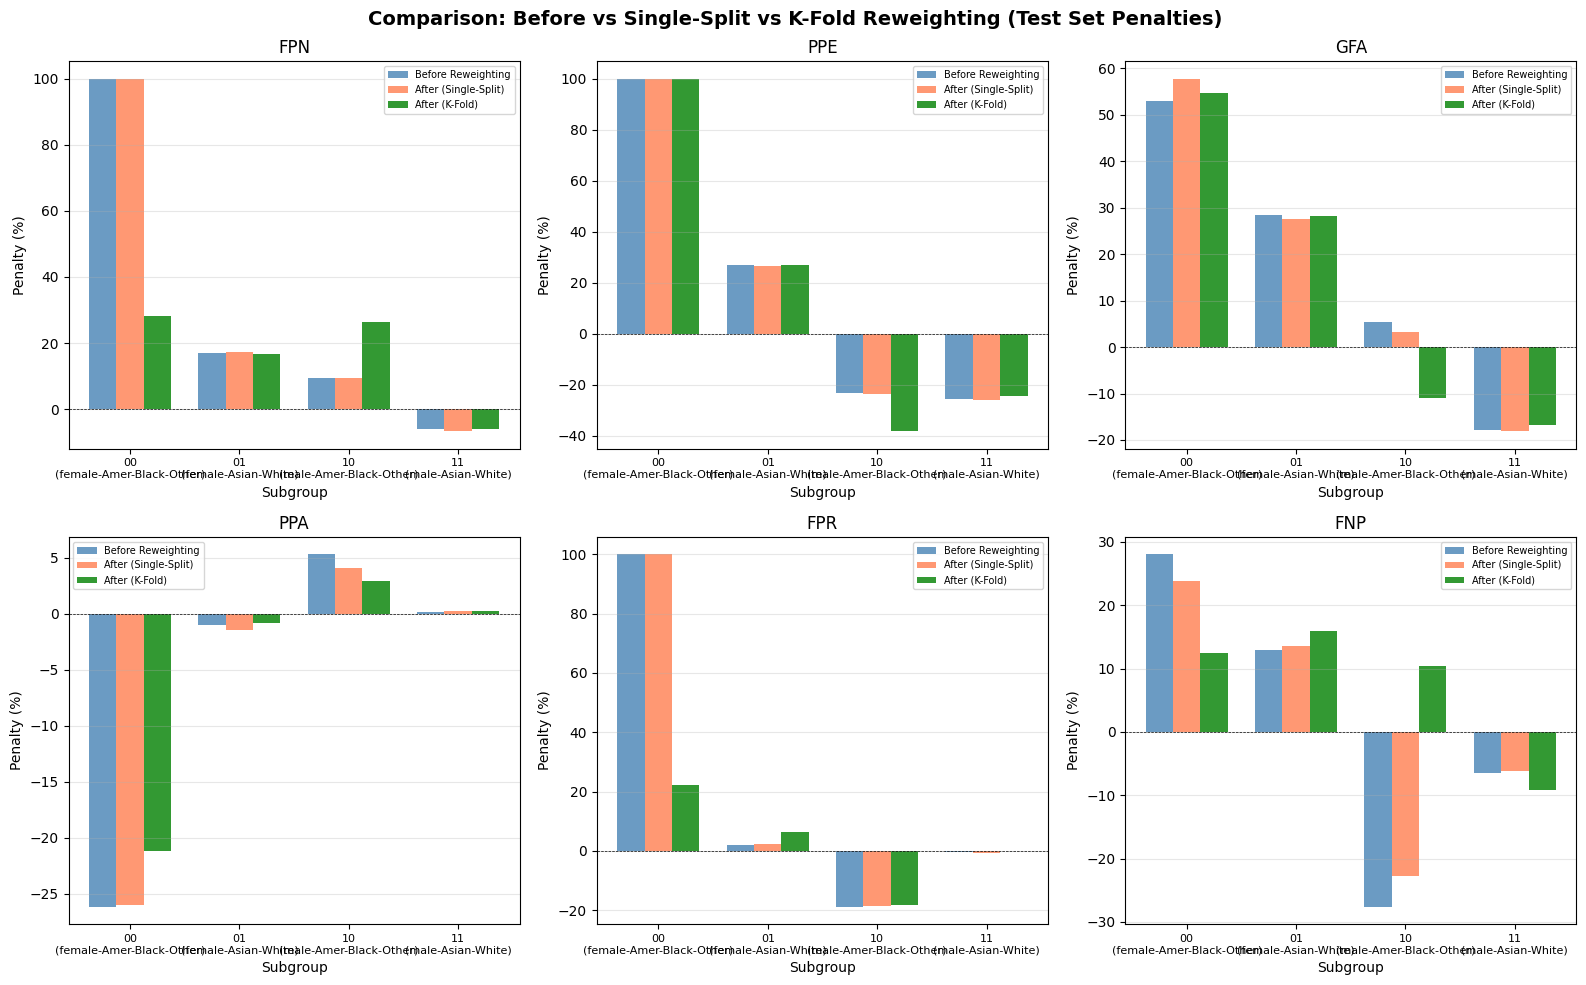


SUMMARY: Average Absolute Penalty Change by Approach
FPN: Before = 33.10 | Single-Split = 33.28 | K-Fold = 19.35
PPE: Before = 43.99 | Single-Split = 43.93 | K-Fold = 47.42
GFA: Before = 26.19 | Single-Split = 26.69 | K-Fold = 27.63
PPA: Before = 8.15 | Single-Split = 7.94 | K-Fold = 6.28
FPR: Before = 30.28 | Single-Split = 30.43 | K-Fold = 11.64
FNP: Before = 18.76 | Single-Split = 16.57 | K-Fold = 12.00


In [75]:
# Visualization: Single-Split vs K-Fold Reweighting Effects
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

individual_attrs = sensible_attribute.split('-')

for idx, m in enumerate(fair_metrics[:6]):
    ax = axes[idx]
    
    groups = ['00', '01', '10', '11']
    x = np.arange(len(groups))
    width = 0.25
    
    before_vals = [penalties_ontest[m].get(g, 0) for g in groups]
    after_single = [penalties_ontest_after_reweighting[m].get(g, 0) for g in groups]
    after_kfold = [penalties_ontest_after_kfold[m].get(g, 0) for g in groups]
    
    bars1 = ax.bar(x - width, before_vals, width, label='Before Reweighting', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x, after_single, width, label='After (Single-Split)', color='coral', alpha=0.8)
    bars3 = ax.bar(x + width, after_kfold, width, label='After (K-Fold)', color='green', alpha=0.8)
    
    # Decode group labels
    labels = [f"{g}\n({'-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))])})" 
              for g in groups]
    
    ax.set_xlabel('Subgroup')
    ax.set_ylabel('Penalty (%)')
    ax.set_title(f'{m}')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comparison: Before vs Single-Split vs K-Fold Reweighting (Test Set Penalties)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*80)
print("SUMMARY: Average Absolute Penalty Change by Approach")
print("="*80)

for m in fair_metrics[:6]:
    before_vals = np.array([abs(penalties_ontest[m].get(g, 0)) for g in groups])
    after_single = np.array([abs(penalties_ontest_after_reweighting[m].get(g, 0)) for g in groups])
    after_kfold = np.array([abs(penalties_ontest_after_kfold[m].get(g, 0)) for g in groups])
    
    print(f"{m}: Before = {before_vals.mean():.2f} | Single-Split = {after_single.mean():.2f} | K-Fold = {after_kfold.mean():.2f}")

In [76]:
# Compare: Single-split penalties vs K-fold averaged penalties
print("="*100)
print("COMPARISON: Single-Split vs K-Fold Averaged Penalties")
print("="*100)

individual_attrs = sensible_attribute.split('-')

for m in fair_metrics[:5]:  # Show first 5 metrics
    print(f"\n{m}:")
    print(f"  {'Group':<25} | {'Single-Split':>12} | {'K-Fold Avg':>12} | {'K-Fold Std':>12} | {'Difference':>12}")
    print("  " + "-"*85)
    
    for group in ['00', '01', '10', '11']:
        # Decode group name
        decoded = '-'.join([mapping[individual_attrs[i]][int(group[i])] for i in range(len(individual_attrs))])
        
        single_val = penalties_onval[m].get(group, 0)
        kfold_avg = penalties_kfold_avg[m][group]
        kfold_std = np.std(penalties_per_fold[m][group])
        diff = kfold_avg - single_val
        
        print(f"  {group} ({decoded:18s}) | {single_val:+12.2f} | {kfold_avg:+12.2f} | {kfold_std:12.2f} | {diff:+12.2f}")

print("\n" + "="*100)
print("NOTE: Lower std = more stable penalty estimate")
print("      Large difference = single-split was noisy")
print("="*100)

COMPARISON: Single-Split vs K-Fold Averaged Penalties

FPN:
  Group                     | Single-Split |   K-Fold Avg |   K-Fold Std |   Difference
  -------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |        -8.75 |       +12.97 |        55.40 |       +21.72
  01 (female-Asian-White) |       +16.48 |       +15.32 |         8.68 |        -1.16
  10 (male-Amer-Black-Other) |       +25.06 |       +16.93 |        22.21 |        -8.13
  11 (male-Asian-White  ) |        -4.57 |        -4.12 |         0.90 |        +0.45

PPE:
  Group                     | Single-Split |   K-Fold Avg |   K-Fold Std |   Difference
  -------------------------------------------------------------------------------------
  00 (female-Amer-Black-Other) |       +59.34 |       +57.54 |        27.58 |        -1.80
  01 (female-Asian-White) |       +28.30 |       +30.29 |         6.66 |        +1.99
  10 (male-Amer-Black-Other) |        +7.36 |        

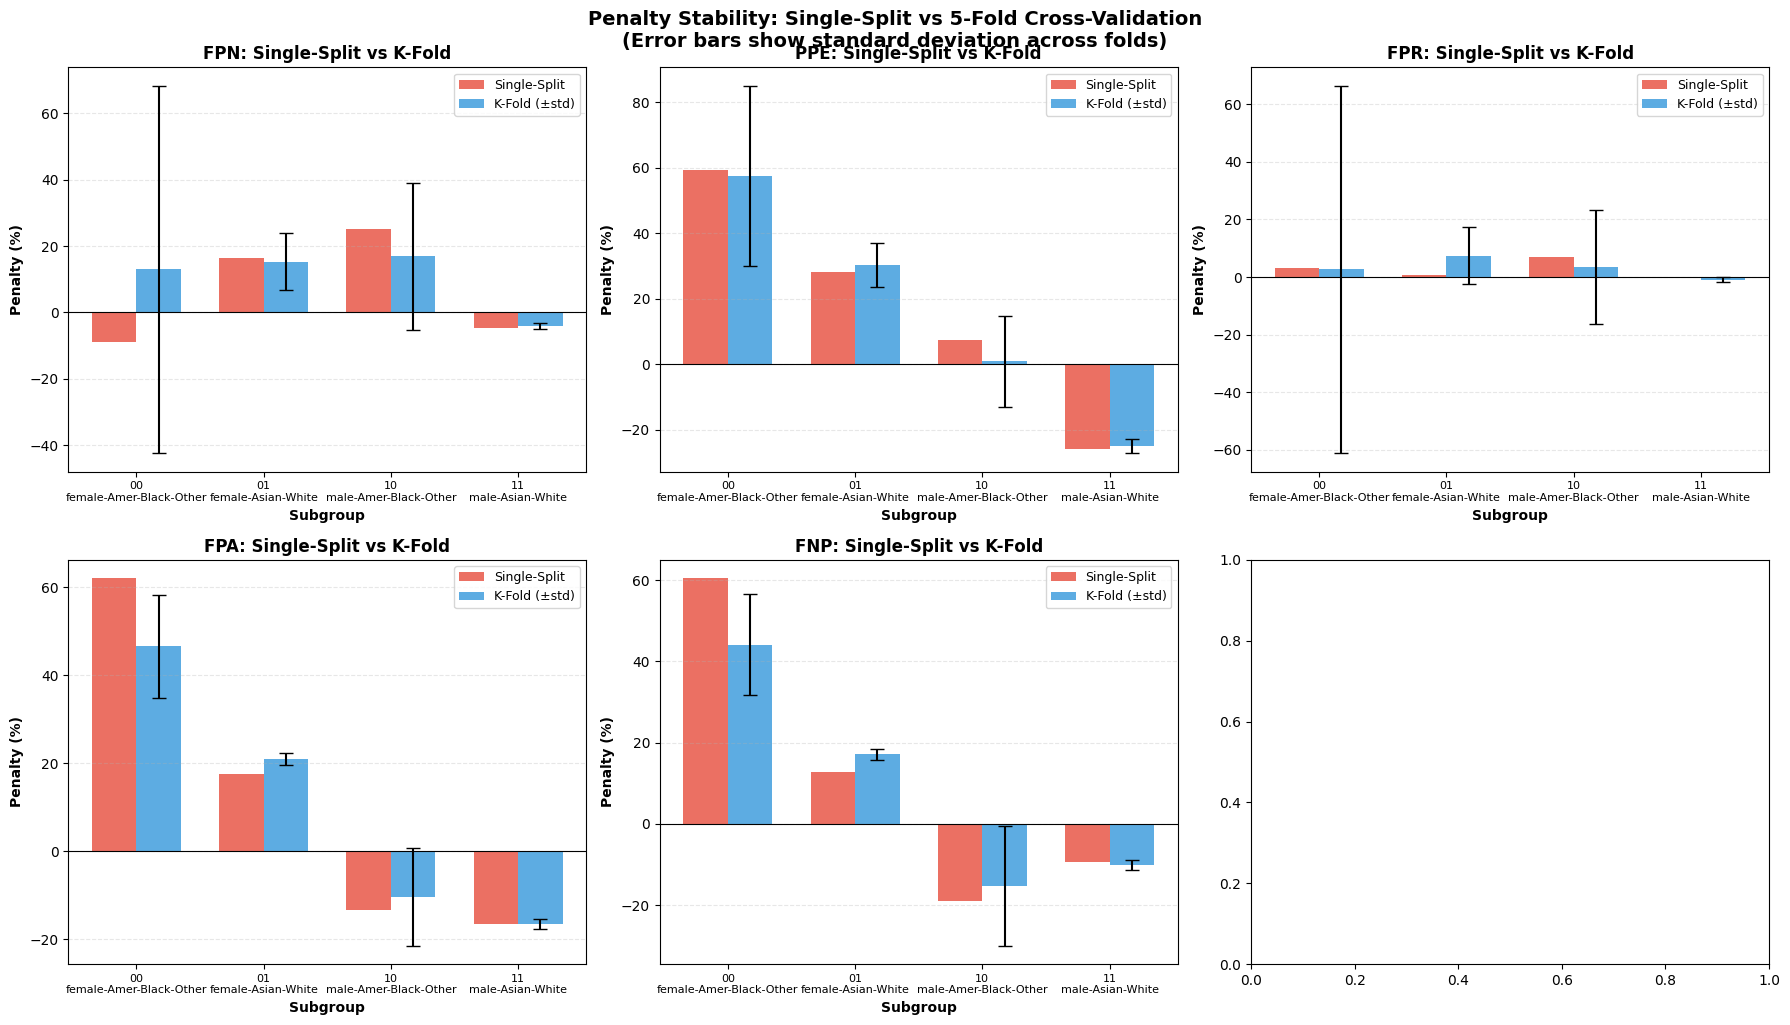

In [77]:
# Visualize penalty stability: K-fold variance by subgroup
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

individual_attrs = sensible_attribute.split('-')
metrics_to_plot = ['FPN', 'PPE', 'FPR', 'FPA', 'FNP']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    groups = ['00', '01', '10', '11']
    x = np.arange(len(groups))
    
    # Get data for this metric
    single_vals = [penalties_onval[metric].get(g, 0) for g in groups]
    kfold_avgs = [penalties_kfold_avg[metric][g] for g in groups]
    kfold_stds = [np.std(penalties_per_fold[metric][g]) for g in groups]
    
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, single_vals, width, label='Single-Split', alpha=0.8, color='#e74c3c')
    bars2 = ax.bar(x + width/2, kfold_avgs, width, yerr=kfold_stds, capsize=5, 
                   label='K-Fold (±std)', alpha=0.8, color='#3498db')
    
    # Decode labels
    decoded_labels = ['-'.join([mapping[individual_attrs[i]][int(g[i])] for i in range(len(individual_attrs))]) 
                      for g in groups]
    
    ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
    ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
    ax.set_title(f'{metric}: Single-Split vs K-Fold', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n{l}" for g, l in zip(groups, decoded_labels)], fontsize=8)
    ax.legend(fontsize=9)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.suptitle('Penalty Stability: Single-Split vs 5-Fold Cross-Validation\n(Error bars show standard deviation across folds)', 
            fontsize=14, fontweight='bold', y=1.02)
plt.show()